In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import sklearn
import transformers
import torch
import nltk
import textstat

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("=" * 45)
print("✅  Environment Check")
print("=" * 45)
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {np.__version__}")
print(f"scikit-learn  : {sklearn.__version__}")
print(f"transformers  : {transformers.__version__}")
print(f"torch         : {torch.__version__}")
print(f"GPU available : {torch.cuda.is_available()}")
print("=" * 45)
print("All libraries loaded successfully ✅")

d:\Project\Fake News Detection\fakenews_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to C:\Users\Mani
[nltk_data]     Butt\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Mani
[nltk_data]     Butt\AppData\Roaming\nltk_data...


✅  Environment Check
pandas        : 3.0.3
numpy         : 2.4.6
scikit-learn  : 1.9.0
transformers  : 5.12.1
torch         : 2.12.0+cpu
GPU available : False
All libraries loaded successfully ✅


[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Mani
[nltk_data]     Butt\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
import pandas as pd

# Column names from the README
col_names = [
    'id', 'label', 'statement', 'subject',
    'speaker', 'job_title', 'state', 'party',
    'barely_true_count', 'false_count', 'half_true_count',
    'mostly_true_count', 'pants_fire_count', 'context'
]

train_df = pd.read_csv('D:/Project\Fake News Detection/data/raw/liar/train.tsv', sep='\t', header=None, names=col_names)
val_df   = pd.read_csv('D:/Project\Fake News Detection/data/raw/liar/valid.tsv', sep='\t', header=None, names=col_names)
test_df  = pd.read_csv('D:/Project\Fake News Detection/data/raw/liar/test.tsv',  sep='\t', header=None, names=col_names)

print("✅ LIAR dataset loaded from local files!")
print(f"\n  Train samples : {len(train_df)}")
print(f"  Val   samples : {len(val_df)}")
print(f"  Test  samples : {len(test_df)}")
print(f"  Total         : {len(train_df)+len(val_df)+len(test_df)}")
print(f"\nColumns: {list(train_df.columns)}")

✅ LIAR dataset loaded from local files!

  Train samples : 10240
  Val   samples : 1284
  Test  samples : 1267
  Total         : 12791

Columns: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'barely_true_count', 'false_count', 'half_true_count', 'mostly_true_count', 'pants_fire_count', 'context']


In [3]:
print("--- Sample rows ---")
display(train_df[['label', 'statement', 'speaker', 'party']].head(5))

print("\n--- 6 Label types in dataset ---")
print(train_df['label'].value_counts())

print("\n--- Top speakers ---")
print(train_df['speaker'].value_counts().head(5))

print("\n--- Party distribution ---")
print(train_df['party'].value_counts().head(6))

--- Sample rows ---


,label,statement,speaker,party
0,false,Says the Annies List political group supports ...,dwayne-bohac,republican
1,half-true,When did the decline of coal start? It started...,scott-surovell,democrat
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",barack-obama,democrat
3,false,Health care reform legislation is likely to ma...,blog-posting,none
4,half-true,The economic turnaround started at the end of ...,charlie-crist,democrat



--- 6 Label types in dataset ---
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

--- Top speakers ---
speaker
barack-obama       488
donald-trump       273
hillary-clinton    239
mitt-romney        176
scott-walker       149
Name: count, dtype: int64

--- Party distribution ---
party
republican      4497
democrat        3336
none            1744
organization     219
independent      147
newsmaker         56
Name: count, dtype: int64


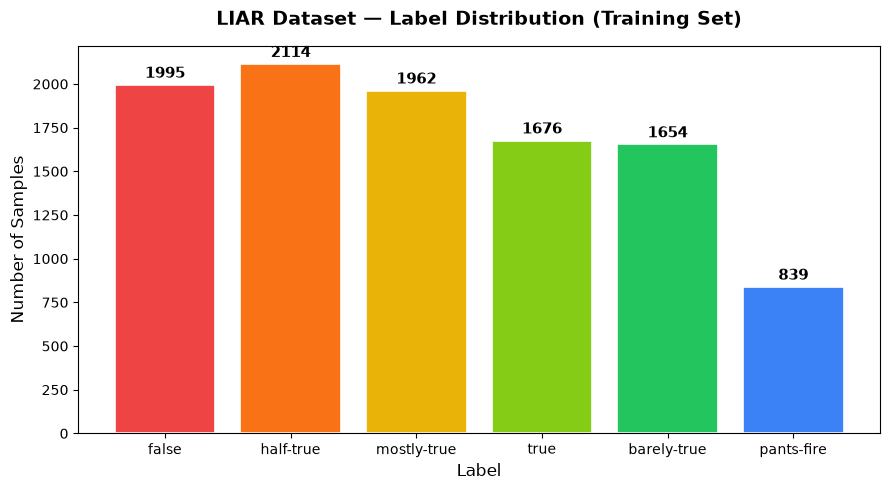

✅ Chart saved to results/


In [4]:
import matplotlib.pyplot as plt

label_order = ['false', 'half-true', 'mostly-true', 'true', 'barely-true', 'pants-fire']
counts = train_df['label'].value_counts().reindex(label_order)

colors = ['#EF4444','#F97316','#EAB308','#84CC16','#22C55E','#3B82F6']
plt.figure(figsize=(9, 5))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('LIAR Dataset — Label Distribution (Training Set)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.tight_layout()
plt.savefig('D:/Project/Fake News Detection/results/1', dpi=150)
plt.show()
print("✅ Chart saved to results/")

In [5]:
fake_labels = ['false', 'barely-true', 'pants-fire']
real_labels = ['true', 'mostly-true', 'half-true']

def map_binary(label):
    return 0 if label in fake_labels else 1

for df in [train_df, val_df, test_df]:
    df['binary_label'] = df['label'].apply(map_binary)

fake_count = (train_df['binary_label'] == 0).sum()
real_count = (train_df['binary_label'] == 1).sum()

print("✅ Binary labels created  (0 = Fake,  1 = Real)")
print(f"\n  Fake : {fake_count}  ({fake_count/(fake_count+real_count)*100:.1f}%)")
print(f"  Real : {real_count}  ({real_count/(fake_count+real_count)*100:.1f}%)")

✅ Binary labels created  (0 = Fake,  1 = Real)

  Fake : 4488  (43.8%)
  Real : 5752  (56.2%)


In [6]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()                          # lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)     # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    return ' '.join(tokens)

train_df['clean_text'] = train_df['statement'].apply(clean_text)
val_df['clean_text']   = val_df['statement'].apply(clean_text)
test_df['clean_text']  = test_df['statement'].apply(clean_text)

print("✅ Text cleaning complete")
print("\nOriginal :", train_df['statement'].iloc[0])
print("Cleaned  :", train_df['clean_text'].iloc[0])

✅ Text cleaning complete

Original : Says the Annies List political group supports third-trimester abortions on demand.
Cleaned  : says annies list political group supports thirdtrimester abortions demand


In [7]:
train_df.to_csv('D:/Project/Fake News Detection/data/processed/train_cleaned.csv', index=False)
val_df.to_csv('D:/Project/Fake News Detection/data/processed/val_cleaned.csv',     index=False)
test_df.to_csv('D:/Project/Fake News Detection/data/processed/test_cleaned.csv',   index=False)

print("✅ Cleaned datasets saved to data/")
print(f"\n  data/train_cleaned.csv  ({len(train_df)} rows)")
print(f"  data/val_cleaned.csv    ({len(val_df)} rows)")
print(f"  data/test_cleaned.csv   ({len(test_df)} rows)")
print("\n🎉 Week 1 Complete! Ready to show supervisor.")

✅ Cleaned datasets saved to data/

  data/train_cleaned.csv  (10240 rows)
  data/val_cleaned.csv    (1284 rows)
  data/test_cleaned.csv   (1267 rows)

🎉 Week 1 Complete! Ready to show supervisor.
